# Notebook that prepares the images from COCO for the input of the Encoder

## Objetivo
Este notebook prepara las imágenes del dataset COCO extrayendo máscaras binarias de objetos (person, car, chair, dining table) para usarlas como entrada en el encoder de simulación de implantes retinales. Las máscaras se redimensionan a 256×256 y se filtran por área mínima.

## Proceso
1. Descarga autenticación en Google Drive
2. Importa dependencias necesarias
3. Define rutas de datos
4. Carga el archivo de anotaciones COCO en formato JSON
5. Extrae máscaras binarias de las clases de interés
6. Redimensiona y filtra por tamaño
7. Guarda metadata en CSV para referencia futura

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Autenticación Google Drive
Monta Google Drive para acceso a datos compartidos

In [ ]:
# imports

import os
import json
import csv
import numpy as np
from pathlib import Path
from PIL import Image
import sys
import pycocotools.mask as mask_util
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
!pip install -q pycocotools

### Importaciones
Carga las librerías necesarias: pathlib para rutas, PIL para imágenes, pycocotools para parsear anotaciones COCO, pandas para manejo de datos

In [ ]:
# paths

PROJECT_ROOT = Path("/content/drive/MyDrive/tp_final_vision_artificial")

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
COCO_DIR = RAW_DIR / "coco"

ANNOTATIONS_DIR = COCO_DIR / "annotations"
IMAGES_DIR = COCO_DIR / "val2017"

MASKS_DIR = DATA_DIR / "masks"
METADATA_DIR = DATA_DIR / "metadata"

SRC_DIR = PROJECT_ROOT / "src"

for d in [ANNOTATIONS_DIR, IMAGES_DIR, MASKS_DIR, METADATA_DIR, SRC_DIR]:
    d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: /content/drive/MyDrive/tp_final_vision_artificial


### Definición de rutas
Establece la estructura de directorios:
- `RAW_DIR`: datos brutos (anotaciones y imágenes COCO)
- `MASKS_DIR`: donde se guardarán las máscaras extraídas
- `METADATA_DIR`: donde se guardará el CSV con información de las máscaras

In [ ]:
from src.data.coco_extraction import (
    extract_coco_masks,
    print_extraction_summary,
)

### Importación de funciones del proyecto
Importa funciones personalizadas para extraer y procesar máscaras COCO

In [ ]:
# config
ANNOTATIONS_FILE = ANNOTATIONS_DIR / "instances_val2017.json"

OUTPUT_MASKS_DIR = MASKS_DIR
OUTPUT_METADATA_FILE = METADATA_DIR / "metadata_masks.csv"

TARGET_CLASSES = ["person", "car", "chair", "dining table"]

TARGET_SIZE = 256
MIN_BBOX_AREA = 1000

print("Annotations file:", ANNOTATIONS_FILE)
print("Existe:", ANNOTATIONS_FILE.exists())
print("Output masks:", OUTPUT_MASKS_DIR)
print("Output metadata:", OUTPUT_METADATA_FILE)

Annotations file: /content/drive/MyDrive/tp_final_vision_artificial/data/raw/coco/annotations/instances_val2017.json
Existe: True
Output masks: /content/drive/MyDrive/tp_final_vision_artificial/data/masks
Output metadata: /content/drive/MyDrive/tp_final_vision_artificial/data/metadata/metadata_masks.csv


### Configuración de extracción
Define parámetros clave:
- **TARGET_CLASSES**: Solo extrae estas 4 clases de objetos
- **TARGET_SIZE**: Redimensiona todas las máscaras a 256×256 píxeles
- **MIN_BBOX_AREA**: Filtra objetos muy pequeños (área mínima de 1000 píxeles)

In [ ]:
# extraccion
summary = extract_coco_masks(
    annotations_file=ANNOTATIONS_FILE,
    output_masks_dir=OUTPUT_MASKS_DIR,
    output_metadata_file=OUTPUT_METADATA_FILE,
    target_classes=TARGET_CLASSES,
    target_size=TARGET_SIZE,
    min_bbox_area=MIN_BBOX_AREA,
)

print_extraction_summary(summary)

Cargando anotaciones COCO...
Anotaciones encontradas para las clases objetivo: 15424
500 máscaras guardadas...
1000 máscaras guardadas...
1500 máscaras guardadas...
2000 máscaras guardadas...
2500 máscaras guardadas...
3000 máscaras guardadas...
3500 máscaras guardadas...
4000 máscaras guardadas...
4500 máscaras guardadas...
5000 máscaras guardadas...
5500 máscaras guardadas...
6000 máscaras guardadas...
6500 máscaras guardadas...
7000 máscaras guardadas...
7500 máscaras guardadas...
8000 máscaras guardadas...
8500 máscaras guardadas...
9000 máscaras guardadas...
9500 máscaras guardadas...
10000 máscaras guardadas...
10500 máscaras guardadas...

Listo.
Guardadas: 10642
Descartadas: 4782
Metadata: /content/drive/MyDrive/tp_final_vision_artificial/data/metadata/metadata_masks.csv
Masks dir: /content/drive/MyDrive/tp_final_vision_artificial/data/masks

Distribución por clase:
car                  920
chair                1329
dining table         624
person               7769


### Extracción de máscaras
Ejecuta la extracción de máscaras COCO. Por cada objeto encontrado:
1. Decodifica la máscara RLE de COCO
2. Redimensiona a 256×256
3. Guarda como archivo PNG
4. Registra metadatos (clase, imagen_id, anotación_id) en CSV

In [ ]:
#chequeo
df = pd.read_csv(OUTPUT_METADATA_FILE)

print(df.shape)
display(df.head())

print("\nCantidad por clase:")
display(df["class"].value_counts())

(10642, 12)


,sample_id,filename,class,image_id,ann_id,orig_img_w,orig_img_h,bbox_x,bbox_y,bbox_w,bbox_h,bbox_area
0,186980_100906,/content/drive/MyDrive/tp_final_vision_artific...,chair,186980,100906,457,640,45,287,196,344,67424
1,575970_101280,/content/drive/MyDrive/tp_final_vision_artific...,chair,575970,101280,640,480,278,314,106,159,16854
2,186980_101424,/content/drive/MyDrive/tp_final_vision_artific...,chair,186980,101424,457,640,233,262,124,256,31744
3,441247_101686,/content/drive/MyDrive/tp_final_vision_artific...,chair,441247,101686,640,424,221,220,79,127,10033
4,136355_101996,/content/drive/MyDrive/tp_final_vision_artific...,chair,136355,101996,640,427,362,235,44,185,8140



Cantidad por clase:


,count
class,
person,7769
chair,1329
car,920
dining table,624


### Validación de datos extraídos
Carga y visualiza el CSV de metadatos generado. Muestra:
- Cantidad total de máscaras extraídas
- Primeras filas de la tabla
- Distribución por clase

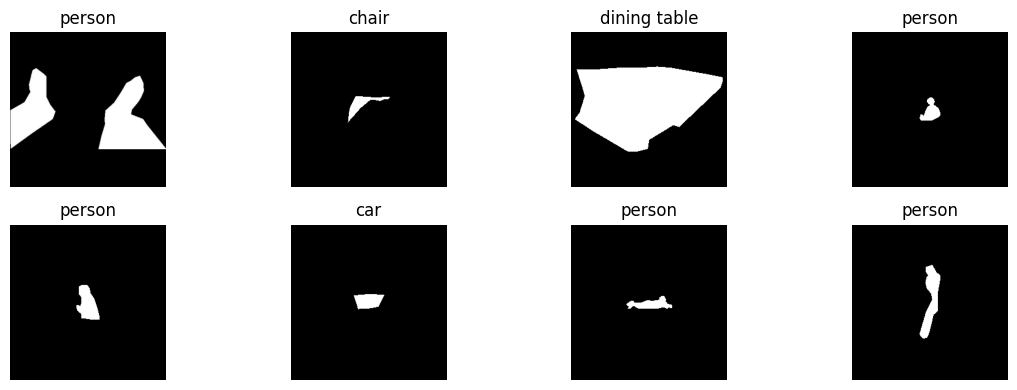

In [ ]:
# visualizacion

sample = df.sample(min(8, len(df)), random_state=42)

plt.figure(figsize=(12, 4))

for i, (_, row) in enumerate(sample.iterrows(), start=1):
    img = Image.open(row["filename"])

    plt.subplot(2, 4, i)
    plt.imshow(img, cmap="gray")
    plt.title(row["class"])
    plt.axis("off")

plt.tight_layout()
plt.show()

### Visualización de muestras
Muestra 8 máscaras aleatorias en escala de grises. Las máscaras son binarias (blanco/negro) y representan los objetos sin la imagen de fondo.